# PayNova Business Reasoning Agent — Arquitectura Evolucionada

Extiende la arquitectura ReAct original con 10 modificaciones del estado del arte.
Los 14 nodos originales se conservan intactos; se agregan 7 nodos nuevos.

| | Original | Evolucionado |
|---|---|---|
| Nodos | 14 | 21 |
| Aristas fijas | 10 | 15 |
| Aristas condicionales | 4 | 6 |
| Decisiones de routing | 4 | 6 |

**Modificaciones:**
| Mod | Nodo nuevo | Posicion en el flujo |
|---|---|---|
| 1 | `business_knowledge_validation` | retrieve_knowledge → [BKV] → plan_analysis \| synthesis_step |
| 2 | `memory_retrieval` | analyze_intent → [MR] → retrieve_knowledge |
| 3 | `plan_analysis` mejorado | subproblemas explicitos antes de PlanStep |
| 4 | `table_validation` | select_tables → [TV] → generate_sql \| select_tables |
| 5 | `business_validation` | execute_sql (exito) → [BV] → advance_step |
| 6+7 | `critic_agent` | reflect → [CA] → confidence_estimator \| replan \| select_tables \| generate_sql |
| 8 | `confidence_estimator` | critic_agent → [CE] → format_response |
| 9 | `format_response` mejorado | formato ejecutivo CEO/CFO/COO |
| 10 | `dashboard_context` | retrieve_knowledge → [DC] → business_knowledge_validation (siempre, sin bifurcar) |

**Mod 10 — Dashboard Context Validator:** detecta si la pregunta corresponde a informacion
visualizada en alguno de los dashboards Power BI de PayNova (`Merchants_1/2/3`, formato PBIP
leido por `mcp_powerbi/parser.py`) y, de ser asi, reformula la pregunta en terminos del modelo
de datos real (medidas DAX + tablas SQL) para que `plan_analysis` y `generate_sql` queden
alineados con lo que el dashboard efectivamente muestra. A diferencia del Mod 1 (KB), esta
etapa **nunca** salta el pipeline SQL — los dashboards muestran datos vivos — por eso no agrega
una nueva decision de routing: solo enriquece `enriched_context` antes de continuar el flujo.

In [11]:
import sys
from pathlib import Path
from typing import List, Optional, TypedDict

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image, Markdown

ROOT = Path('../').resolve()
sys.path.insert(0, str(ROOT))

# Constantes originales
MAX_REACT_ITERATIONS  = 6
MAX_RETRIES_SQL       = 3
MAX_SQL_STEPS         = 5
CONFIDENCE_THRESHOLDS = {
    'respond_normal': 85, 'respond_limited': 70,
    'request_partial': 50, 'request_clarification': 0,
}

# Constantes nuevas
MAX_TABLE_RETRIES = 2   # Mod 4: reintentos max de seleccion de tablas
MAX_CRITIC_ITERS  = 2   # Mod 6/7: iteraciones max del critic agent

print('Setup OK')
print(f'  MAX_REACT_ITERATIONS = {MAX_REACT_ITERATIONS}')
print(f'  MAX_RETRIES_SQL      = {MAX_RETRIES_SQL}')
print(f'  MAX_TABLE_RETRIES    = {MAX_TABLE_RETRIES}')
print(f'  MAX_CRITIC_ITERS     = {MAX_CRITIC_ITERS}')

Setup OK
  MAX_REACT_ITERATIONS = 6
  MAX_RETRIES_SQL      = 3
  MAX_TABLE_RETRIES    = 2
  MAX_CRITIC_ITERS     = 2


---
## 1. Estado del Agente

Todos los campos originales se conservan. Se agregan campos para las 9 modificaciones.

In [12]:
class AgentState(TypedDict):

    # CAMPOS ORIGINALES (sin cambios)
    question:              str
    verbose:               bool
    cache_hit:             bool
    cached_response:       Optional[str]
    intent:                Optional[dict]   # domain, complexity, metrics, entities
    kb_context:            str
    memory_context:        str
    enriched_context:      str
    plan:                  Optional[dict]   # AnalysisPlan con lista de PlanStep
    react_iteration:       int
    current_step_index:    int              # -1 = antes de empezar
    current_table_sel:     Optional[dict]
    current_sql:           Optional[dict]
    current_step_result:   Optional[dict]
    sql_retry_count:       int
    step_results:          List[dict]
    prev_results_summary:  str
    reflection:            Optional[dict]
    response:              Optional[dict]
    trace_steps:           List[dict]

    # CAMPOS NUEVOS
    retrieved_memory:          Optional[dict]  # Mod 2: errores/exitos/feedback historicos
    kb_sufficient:             bool            # Mod 1: True = responder solo con KB, sin SQL
    kb_answer:                 Optional[str]   # Mod 1: respuesta derivada de documentacion
    table_validation_ok:       bool            # Mod 4: tablas cubren todos los requisitos
    table_validation_issues:   List[str]       # Mod 4: problemas detectados
    table_validation_attempts: int             # Mod 4: contador para evitar loop infinito
    business_validation_ok:    bool            # Mod 5: resultados coherentes con negocio
    business_validation_flags: List[str]       # Mod 5: anomalias detectadas
    critic_result:             Optional[dict]  # Mod 6: verdict, scores, reasoning
    critic_iteration:          int             # Mod 7: iteraciones del critic (max MAX_CRITIC_ITERS)
    critic_target_step:        int             # Mod 7: paso a reejecutar (-1 = todos)
    confidence_components:     Optional[dict]  # Mod 8: breakdown por componente
    final_confidence_score:    int             # Mod 8: score compuesto 0-100
    final_confidence_action:   str             # Mod 8: respond | warn | validate | clarify
    dashboard_relevant:        bool            # Mod 10: la pregunta corresponde a un dashboard PBI
    dashboard_reference:       str             # Mod 10: dashboard(s) relacionados, para el banner UI
    dashboard_matched_measures: List[dict]     # Mod 10: medidas DAX relevantes (nombre, expr, tabla SQL)
    dashboard_context_text:    str             # Mod 10: texto listo para anteponer a enriched_context


orig = {'question','verbose','cache_hit','cached_response','intent','kb_context',
        'memory_context','enriched_context','plan','react_iteration','current_step_index',
        'current_table_sel','current_sql','current_step_result','sql_retry_count',
        'step_results','prev_results_summary','reflection','response','trace_steps'}
total  = len(AgentState.__annotations__)
nuevos = total - len(orig)
print(f'AgentState: {total} campos ({len(orig)} originales + {nuevos} nuevos)')

AgentState: 38 campos (20 originales + 18 nuevos)


---
## 2. Nodos Originales (14 — sin modificacion estructural)

In [13]:
def check_cache(state: AgentState) -> dict:
    """MemoryAgent.check_cache — similitud tokens >= 80% -> HIT."""
    cached = None  # stub: siempre MISS
    return {'cache_hit': cached is not None, 'cached_response': cached}


def analyze_intent(state: AgentState) -> dict:
    """IntentAnalyzerAgent — LLM clasifica dominio, complejidad, metricas, entidades."""
    return {'intent': {
        'domain': 'finanzas', 'query_type': 'financiero', 'complexity': 'simple',
        'entities': ['transacciones'], 'metrics': ['gmv'],
        'time_horizon': 'mensual', 'is_ambiguous': False,
        'ambiguity_reason': 'ninguna', 'estimated_sql_steps': 1,
    }}


def retrieve_knowledge(state: AgentState) -> dict:
    """
    BusinessKnowledgeRetriever — FAISS top-5 sobre knowledge_base/ (10 docs .md).
    Ahora incorpora retrieved_memory (Mod 2) para enriquecer el contexto.
    """
    kb  = '[KB] MDR=1.8%, Margen=1.0%, estado=completada, year_month para filtrar.'
    mem = ''
    if state.get('retrieved_memory'):
        errors = state['retrieved_memory'].get('errors', [])
        if errors:
            mem = '[MEM] Error previo: ' + errors[0].get('error', '') + ' -> ' + errors[0].get('correction', '')
    return {
        'kb_context':       kb,
        'memory_context':   mem,
        'enriched_context': kb + ('\n' + mem if mem else ''),
    }


def plan_analysis(state: AgentState) -> dict:
    """
    MultiHopPlanner — Mod 3: descomposicion explicita de subproblemas
    antes de generar los PlanStep. Identifica dependencias y metricas.
    """
    return {
        'plan': {
            'question': state['question'],
            'overall_approach': 'Consulta directa a transacciones completadas.',
            'expected_output': 'GMV total del mes anterior.',
            'subproblems': [   # Mod 3: descomposicion explicita
                'Identificar periodo: mes anterior',
                'Filtrar transacciones completadas',
                'Sumar campo monto',
            ],
            'steps': [{
                'step_number': 1, 'is_synthesis': False, 'sql_needed': True,
                'description': 'Sumar GMV de transacciones completadas del mes anterior',
                'objective': 'Obtener GMV mensual total',
                'tables_hint': ['transacciones.transacciones'], 'depends_on': [],
            }],
        },
        'current_step_index': -1, 'step_results': [],
        'prev_results_summary': '', 'sql_retry_count': 0,
        'table_validation_attempts': 0,
    }


def select_tables(state: AgentState) -> dict:
    """TableRetrievalAgent — selecciona del catalogo PAYNOVA_TABLES (13 objetos)."""
    step = state['plan']['steps'][state['current_step_index']]
    return {'current_table_sel': {
        'selected_tables': step['tables_hint'] or ['transacciones.transacciones'],
        'reasoning': 'Tabla central de transacciones (24M+ registros).',
        'schema_hints': {'transacciones.transacciones': ['monto', 'estado', 'year_month']},
    }}


def generate_sql(state: AgentState) -> dict:
    """SQLReasoningAgent — genera SQL con reglas de negocio PayNova."""
    return {'current_sql': {
        'step_number': state['current_step_index'] + 1,
        'sql': ("SELECT ROUND(SUM(monto), 2) AS gmv FROM transacciones.transacciones "
                "WHERE estado = 'completada' "
                "AND year_month = TO_CHAR(CURRENT_DATE - INTERVAL '1 month', 'YYYY-MM');"),
        'reasoning': 'Suma de monto de transacciones completadas.', 'confidence': 'high',
    }}


def execute_sql(state: AgentState) -> dict:
    """ExecutionAgent — SELECT puro contra PostgreSQL, max 500 filas."""
    sql = state['current_sql']['sql'] if state.get('current_sql') else ''
    return {'current_step_result': {
        'step_number': state['current_step_index'] + 1, 'sql': sql,
        'rows': [{'gmv': 1_250_000.00}], 'columns': ['gmv'], 'row_count': 1,
        'success': True, 'error_message': None,
        'anomalies': [], 'summary': 'Paso 1: 1 resultado -> gmv=1250000.0',
    }}


def correct_sql(state: AgentState) -> dict:
    """SQLReasoningAgent.correct — LLM corrige el SQL con el error como contexto."""
    retry = state['sql_retry_count'] + 1
    return {
        'current_sql': {
            **state['current_sql'],
            'sql': '-- Correccion intento ' + str(retry) + '\n' + state['current_sql']['sql'],
        },
        'sql_retry_count': retry,
    }


def synthesis_step(state: AgentState) -> dict:
    """
    Paso sin SQL. Dos usos:
      A) Multi-hop: consolida prev_results_summary.
      B) KB-directo (Mod 1): usa kb_answer como contenido.
    """
    plan  = state.get('plan') or {}
    steps = plan.get('steps', [])
    idx   = state['current_step_index']
    step  = steps[idx] if idx < len(steps) else {'step_number': 1, 'description': 'KB-directo'}
    content = (state['kb_answer'] if state.get('kb_sufficient') and state.get('kb_answer')
               else state.get('prev_results_summary', ''))
    return {'current_step_result': {
        'step_number': step['step_number'], 'sql': '-- Sin SQL',
        'rows': [{'synthesis': content}], 'columns': ['synthesis'], 'row_count': 1,
        'success': True, 'error_message': None,
        'anomalies': [], 'summary': 'Sintesis: ' + step['description'],
    }}


def advance_step(state: AgentState) -> dict:
    """Consolida result, actualiza prev_summary, incrementa step_index."""
    result  = state.get('current_step_result')
    results = list(state.get('step_results', []))
    prev    = state.get('prev_results_summary', '')
    if result:
        results.append(result)
        if result.get('success') and result.get('summary'):
            prev = prev + '\n' + result['summary']
    return {
        'step_results': results, 'prev_results_summary': prev,
        'current_step_index': state['current_step_index'] + 1,
        'sql_retry_count': 0,
        'current_table_sel': None, 'current_sql': None, 'current_step_result': None,
    }


def reflect(state: AgentState) -> dict:
    """ReflectionAgent — primera capa de evaluacion. Confidence: >=85/70/50/<50."""
    failed = sum(1 for r in state['step_results'] if not r.get('success', False))
    score  = max(0, 90 - failed * 15)
    level  = ('normal' if score >= 85 else 'limited' if score >= 70
               else 'partial' if score >= 50 else 'clarification')
    return {
        'reflection': {
            'question_answered': failed == 0, 'confidence_score': score,
            'confidence_level': level, 'issues_found': [],
            'reasoning': 'Reflexion primera capa.',
            'requires_retry': score < 70 and failed > 0,
            'retry_hint': 'Verificar filtros SQL' if failed > 0 else '',
            'business_rules_ok': True, 'data_quality_ok': failed == 0,
        },
        'react_iteration': state.get('react_iteration', 0) + 1,
    }


def replan(state: AgentState) -> dict:
    """MultiHopPlanner con contexto de correcciones. Resetea el loop de pasos."""
    reflection  = state.get('reflection') or {}
    critic_res  = state.get('critic_result') or {}
    hint = reflection.get('retry_hint', '') + ' | ' + critic_res.get('replan_hint', '')
    return {
        'plan': {**state['plan'],
                 'overall_approach': '[REPLAN] ' + state['plan']['overall_approach'] + ' | ' + hint},
        'current_step_index': -1, 'step_results': [],
        'prev_results_summary': '', 'sql_retry_count': 0,
        'table_validation_attempts': 0,
    }


def format_response(state: AgentState) -> dict:
    """
    ResponseFormatter — Mod 9: formato ejecutivo para CEO/CFO/COO/Comite.
    Secciones: Resumen Ejecutivo | Hallazgos Clave | Evidencia |
               Analisis | Riesgos y Consideraciones | Recomendaciones | Confianza.
    """
    cached  = state.get('cached_response')
    action  = state.get('final_confidence_action', 'respond')
    score   = state.get('final_confidence_score', 0)
    if cached:
        summary = '[CACHE] ' + cached
    elif action == 'clarify':
        summary = ('[ACLARACION REQUERIDA] Confianza insuficiente (score=' + str(score) +
                   '). Especifique el periodo, segmento o metrica de interes.')
    else:
        summary = ('El GMV del mes pasado ascendio a $1,250,000, '
                   'representando el volumen total de transacciones completadas.')
    return {'response': {
        'executive_summary':  summary,
        'key_findings':       ['GMV mensual: $1.25M'],
        'evidence':           state.get('step_results', []),
        'analysis':           'Basado en transacciones.transacciones, filtro estado=completada.',
        'risks':              state.get('business_validation_flags', []),
        'recommendations':    ['Monitorear variacion mes a mes.'],
        'confidence_score':   score,
        'confidence_action':  action,
    }}


def save_memory(state: AgentState) -> dict:
    """MemoryAgent.save — persiste success/error patterns y question_cache."""
    return {}


print('14 nodos originales OK')

14 nodos originales OK


---
## 3. Nodos Nuevos (7 — Modificaciones 1-8, 10)

In [14]:
# ── MOD 2: memory_retrieval ────────────────────────────────────────────────
# Posicion: analyze_intent → [memory_retrieval] → retrieve_knowledge
def memory_retrieval(state: AgentState) -> dict:
    """
    Recupera contexto historico ANTES de recuperar conocimiento de la KB.
    Agente real: MemoryAgent.retrieve_relevant_errors() + retrieve_similar_successes()

    Recupera del memory_store.json:
      - Errores historicos del mismo dominio (evitar repetirlos)
      - Estrategias exitosas de complejidad similar
      - Correcciones y feedback del usuario

    El resultado se inyecta en enriched_context para influir en plan_analysis.
    """
    intent     = state.get('intent') or {}
    domain     = intent.get('domain', 'general')
    complexity = intent.get('complexity', 'simple')
    return {
        'retrieved_memory': {
            'domain': domain, 'complexity': complexity,
            'errors': [
                {'error': 'SUM(monto) en lugar de SUM(ingreso_comision)',
                 'correction': 'Usar ingreso_comision para ingresos de PayNova'},
            ],
            'successes': [
                {'plan': 'Filtrar por year_month y estado=completada', 'confidence': 88},
            ],
            'feedback': [],
        }
    }


# ── MOD 10: dashboard_context ──────────────────────────────────────────────
# Posicion: retrieve_knowledge → [dashboard_context] → business_knowledge_validation
def dashboard_context(state: AgentState) -> dict:
    """
    Detecta si la pregunta corresponde a informacion visualizada en alguno de
    los dashboards Power BI de PayNova (Merchants_1/2/3, formato PBIP leido
    por mcp_powerbi/parser.py) y, de ser asi, reformula la pregunta en
    terminos del modelo de datos real (medidas DAX + tablas SQL reales).
    Agente real: DashboardContextAgent.analyze() (agente/agents/dashboard_validator.py)

    Heuristica (sin LLM): busca coincidencias de texto contra el catalogo de
    medidas/columnas/visuales de los dashboards (DashboardCatalog.search()).
    Si hay candidatos: un LLM confirma relevancia, selecciona las medidas
    aplicables y reformula la pregunta.

    IMPORTANTE: a diferencia de Mod 1 (KB), esta etapa NUNCA salta el pipeline
    SQL — los dashboards muestran datos vivos. Su unico efecto es anteponer
    dashboard_context_text a enriched_context antes de business_knowledge_validation,
    por lo que no agrega una nueva decision de routing (arista fija, no condicional).
    """
    question = state['question'].lower()

    # Catalogo simulado de medidas conocidas en los dashboards (en el agente
    # real proviene de parsear los .tmdl de Merchants_1/2/3 via DashboardCatalog).
    known_measures = {
        'gmv': {
            'name': 'GMV', 'sql_tables': ['transacciones.transacciones'],
            'expression': "CALCULATE(SUM('transacciones transacciones'[monto]), "
                          "'transacciones transacciones'[estado]=\"completada\")",
        },
        'payouts rechazados': {
            'name': 'Payouts Rechazados', 'sql_tables': ['produccion.payouts'],
            'expression': "CALCULATE(COUNTROWS('produccion payouts'), "
                          "'produccion payouts'[estado] IN {\"rechazado\",\"fallido\"})",
        },
        'mdr': {
            'name': 'MDR Generado', 'sql_tables': ['transacciones.transacciones'],
            'expression': "CALCULATE(SUM('transacciones transacciones'[ingreso_comision]), "
                          "'transacciones transacciones'[estado]=\"completada\")",
        },
    }
    matched = [m for kw, m in known_measures.items() if kw in question]

    if not matched:
        return {
            'dashboard_relevant': False, 'dashboard_reference': '',
            'dashboard_matched_measures': [], 'dashboard_context_text': '',
        }

    dashboards = ['Merchants_1', 'Merchants_2', 'Merchants_3']
    lines = [f"[DASHBOARD] Pregunta relacionada con el/los dashboard(s): {', '.join(dashboards)}."]
    lines.append('Medidas ya definidas en el modelo Power BI (usar como referencia exacta):')
    for m in matched:
        lines.append(f"  - {m['name']} = {m['expression']} [tabla SQL: {', '.join(m['sql_tables'])}]")
    context_text = '\n'.join(lines)

    # Se ANTEPONE (no se agrega al final) porque otros agentes truncan
    # enriched_context a un numero fijo de caracteres — igual que en el codigo real.
    prev_context = state.get('enriched_context', '')
    return {
        'dashboard_relevant':         True,
        'dashboard_reference':        ', '.join(dashboards),
        'dashboard_matched_measures': matched,
        'dashboard_context_text':     context_text,
        'enriched_context':           context_text + '\n\n' + prev_context,
    }


# ── MOD 1: business_knowledge_validation ──────────────────────────────────
# Posicion: retrieve_knowledge → [BKV] → synthesis_step | plan_analysis
def business_knowledge_validation(state: AgentState) -> dict:
    """
    Determina si la pregunta puede responderse SIN SQL, solo con documentacion.
    Agente real: LLM evalua la pregunta contra KB recuperada.

    Revisa: ontologia, metricas, reglas de negocio, diccionario de datos,
            documentacion operativa, definiciones corporativas.

    SUFFICIENT (NO SQL, NO tablas, NO BD):
      'Que es el GMV?', 'Como se calcula el MDR?', 'Que significa comercio activo?'

    NEEDS_SQL:
      'Cual fue el GMV del ultimo trimestre?', 'Que campanas tuvieron canibalizacion?'

    Si SUFFICIENT: crea plan con un unico paso synthesis y establece kb_answer.
    Si NEEDS_SQL:  continua normalmente hacia plan_analysis.
    """
    question = state['question'].lower()
    kb       = state.get('enriched_context', '')
    definition_kws = ['que es', 'como se calcula', 'define', 'que significa',
                      'como se define', 'cual es la definicion', 'cuales son los tipos']
    sufficient = any(kw in question for kw in definition_kws)

    if sufficient:
        return {
            'kb_sufficient': True,
            'kb_answer': '[KB] El GMV (Gross Merchandise Value) es el volumen total '
                         'de transacciones procesadas por PayNova.',
            'plan': {
                'question': state['question'],
                'overall_approach': 'Respuesta directa desde knowledge_base.',
                'expected_output': 'Definicion o explicacion conceptual.',
                'subproblems': ['Buscar definicion en KB'],
                'steps': [{
                    'step_number': 1, 'is_synthesis': True, 'sql_needed': False,
                    'description': 'Extraer respuesta de la documentacion empresarial',
                    'objective': 'Respuesta conceptual sin BD',
                    'tables_hint': [], 'depends_on': [],
                }],
            },
            'current_step_index': 0,   # apunta directamente al paso synthesis
            'step_results': [], 'prev_results_summary': kb,
            'sql_retry_count': 0, 'table_validation_attempts': 0,
        }

    return {'kb_sufficient': False, 'kb_answer': None}


# ── MOD 4: table_validation ────────────────────────────────────────────────
# Posicion: select_tables → [TV] → generate_sql | select_tables
def table_validation(state: AgentState) -> dict:
    """
    Valida que las tablas seleccionadas cubran todos los requisitos del paso.
    Agente real: LLM verifica cobertura de metricas, entidades y periodo temporal.

    Verifica:
      - Cobertura de metricas requeridas por el paso
      - Cobertura temporal (datos del periodo solicitado)
      - Cobertura de entidades (comercios, usuarios, transacciones)
      - Consistencia semantica con el objetivo del paso

    Si hay inconsistencia y quedan intentos: volver a select_tables.
    Si se agotan MAX_TABLE_RETRIES: continuar de todas formas (modo degradado).
    """
    table_sel = state.get('current_table_sel') or {}
    tables    = table_sel.get('selected_tables', [])
    steps     = (state.get('plan') or {}).get('steps', [])
    idx       = state['current_step_index']
    hints     = steps[idx].get('tables_hint', []) if idx < len(steps) else []

    issues = [f'Tabla requerida ausente: {t}' for t in hints if t not in tables]
    return {
        'table_validation_ok':       len(issues) == 0,
        'table_validation_issues':   issues,
        'table_validation_attempts': state.get('table_validation_attempts', 0) + 1,
    }


# ── MOD 5: business_validation ─────────────────────────────────────────────
# Posicion: execute_sql (exito) → [BV] → advance_step
def business_validation(state: AgentState) -> dict:
    """
    Valida que los resultados SQL son coherentes con el negocio.
    Agente real: LLM con reglas de negocio y rangos esperados de PayNova.

    Evalua:
      - Rangos esperados: GMV $10M-$500M/mes, tasa fraude 0.1%-5%
      - Anomalias: GMV=$500 billones, margen > MDR, montos negativos
      - Resultados vacios: posible filtro incorrecto
      - Contradiccion con reglas: SUM(monto) usado como ingreso

    IMPORTANTE: Siempre avanza hacia advance_step (no bloquea el flujo).
    Los flags quedan disponibles para critic_agent.
    """
    rows  = (state.get('current_step_result') or {}).get('rows', [])
    flags = []
    for row in rows:
        gmv = row.get('gmv', 0) or 0
        if isinstance(gmv, (int, float)):
            if gmv > 500_000_000:
                flags.append(f'GMV anormalmente alto: ${gmv:,.0f} (esperado < $500M/mes)')
            elif gmv == 0:
                flags.append('GMV = 0: posible filtro incorrecto o datos ausentes')
    if not rows:
        flags.append('Sin resultados: verificar filtros WHERE y rango temporal')
    return {
        'business_validation_ok':    len(flags) == 0,
        'business_validation_flags': flags,
    }


print('Nodos nuevos A-E OK (memory_retrieval, dashboard_context, bkv, table_validation, business_validation)')

Nodos nuevos A-E OK (memory_retrieval, dashboard_context, bkv, table_validation, business_validation)


In [15]:
# ── MOD 6+7: critic_agent ──────────────────────────────────────────────────
# Posicion: reflect → [CA] → confidence_estimator | replan | select_tables | generate_sql
def critic_agent(state: AgentState) -> dict:
    """
    LLM INDEPENDIENTE (no participo en la generacion) — segunda capa critica.
    Mod 6: evalua cinco dimensiones de calidad.
    Mod 7: puede disparar bucle de correccion hacia replan/select_tables/generate_sql.

    Recibe todo el contexto del analisis completo:
      pregunta | plan + subproblemas | KB recuperada | tablas seleccionadas |
      SQL generado | resultados SQL | flags empresariales | reflexion primera capa

    Evalua:
      1. Exactitud:          se respondio realmente la pregunta?
      2. Consistencia:       la respuesta coincide con la evidencia?
      3. Calidad Analitica:  el razonamiento es correcto?
      4. Riesgo Alucinacion: hay informacion inventada?
      5. Calidad Ejecutiva:  la respuesta es util para el negocio?

    Veredictos:
      'sufficient' -> confidence_estimator
      'replan'     -> plan incorrecto, regenerar desde cero
      'retable'    -> tablas insuficientes en paso N (resetea a select_tables)
      'retry_sql'  -> SQL incorrecto en paso N (resetea a generate_sql)
    """
    reflection   = state.get('reflection') or {}
    biz_flags    = state.get('business_validation_flags', [])
    step_results = state.get('step_results', [])
    failed       = sum(1 for r in step_results if not r.get('success', False))
    ref_score    = reflection.get('confidence_score', 90)

    # Determinar veredicto
    if biz_flags and failed == 0:
        verdict = 'retry_sql'
        target  = len(step_results) - 1
        hint    = 'Revisar rangos en WHERE y campos de agregacion'
    elif failed > 0 and ref_score < 50:
        verdict = 'replan'
        target  = -1
        hint    = 'Plan con errores multiples, regenerar estrategia'
    else:
        verdict = 'sufficient'
        target  = -1
        hint    = ''

    update = {
        'critic_result': {
            'verdict':            verdict,
            'exactness':          90 if verdict == 'sufficient' else 60,
            'consistency':        88 if verdict == 'sufficient' else 55,
            'analytic_quality':   85,
            'hallucination_risk': 'low' if verdict == 'sufficient' else 'medium',
            'executive_quality':  80,
            'replan_hint':        hint,
            'reasoning':          'Critic: ' + verdict,
        },
        'critic_iteration':  state.get('critic_iteration', 0) + 1,
        'critic_target_step': target,
    }

    # Preparar estado para reejecutar paso especifico
    if verdict == 'retable' and target >= 0:
        kept = [r for r in step_results if r.get('step_number', 0) <= target]
        update.update({
            'current_step_index': target, 'step_results': kept,
            'current_table_sel': None, 'current_sql': None,
            'current_step_result': None, 'sql_retry_count': 0,
            'table_validation_attempts': 0,
        })
    elif verdict == 'retry_sql' and target >= 0:
        kept = [r for r in step_results if r.get('step_number', 0) <= target]
        update.update({
            'current_step_index': target, 'step_results': kept,
            'current_sql': None, 'current_step_result': None, 'sql_retry_count': 0,
        })

    return update


# ── MOD 8: confidence_estimator ────────────────────────────────────────────
# Posicion: critic_agent → [CE] → format_response
def confidence_estimator(state: AgentState) -> dict:
    """
    Score de confianza COMPUESTO (6 componentes, pesos diferenciados).

    Componentes:
      Retrieval KB        15%  — calidad del contexto recuperado
      Plan                15%  — coherencia del plan de analisis
      SQL                 20%  — exito/fallo de los pasos SQL
      Business validation 20%  — coherencia con rangos del negocio
      Critic evaluation   20%  — evaluacion del LLM independiente
      Penalizacion iters  10%  — descuento por reintentos excesivos

    Reglas de accion:
      90-100 -> 'respond'   (responder con plena confianza)
      80-89  -> 'warn'      (responder con observaciones menores)
      50-79  -> 'validate'  (responder con advertencias, solicitar validacion)
      <50    -> 'clarify'   (solicitar aclaracion al usuario, no responder)
    """
    reflection   = state.get('reflection') or {}
    critic       = state.get('critic_result') or {}
    biz_ok       = state.get('business_validation_ok', True)
    react_iters  = state.get('react_iteration', 1)
    critic_iters = state.get('critic_iteration', 1)
    failed       = sum(1 for r in state.get('step_results', []) if not r.get('success', False))

    retrieval_score = 90
    plan_score      = 85
    sql_score       = max(40, 100 - failed * 20)
    biz_score       = 90 if biz_ok else 50
    critic_score    = critic.get('exactness', 80)
    iter_penalty    = min(20, (react_iters - 1) * 5 + (critic_iters - 1) * 5)

    composite = (retrieval_score * 0.15 + plan_score * 0.15 + sql_score * 0.20
                 + biz_score * 0.20 + critic_score * 0.20 + (100 - iter_penalty) * 0.10)
    score = int(max(0, min(100, composite)))

    action = ('respond' if score >= 90 else 'warn' if score >= 80
               else 'validate' if score >= 50 else 'clarify')

    return {
        'confidence_components': {
            'retrieval': retrieval_score, 'plan': plan_score, 'sql': sql_score,
            'business': biz_score, 'critic': critic_score, 'iter_penalty': iter_penalty,
        },
        'final_confidence_score':  score,
        'final_confidence_action': action,
    }


print('Nodos nuevos F-G OK (critic_agent, confidence_estimator)')
print('Total: 14 originales + 7 nuevos = 21 nodos')

Nodos nuevos F-G OK (critic_agent, confidence_estimator)
Total: 14 originales + 7 nuevos = 21 nodos


---
## 4. Funciones de Routing (2 originales + 4 nuevas/actualizadas)

In [16]:
# D1 — original, sin cambios
def route_cache(state: AgentState) -> str:
    """cache_hit -> format_response | MISS -> analyze_intent."""
    return 'format_response' if state.get('cache_hit') else 'analyze_intent'


# D2 — NUEVO (Mod 1)
def route_kb_validation(state: AgentState) -> str:
    """
    kb_sufficient=True  -> synthesis_step  (omite TODO el pipeline SQL)
    kb_sufficient=False -> plan_analysis   (flujo normal con SQL)
    """
    return 'synthesis_step' if state.get('kb_sufficient') else 'plan_analysis'


# D3 — NUEVO (Mod 4)
def route_table_validation(state: AgentState) -> str:
    """
    ok=True o attempts >= MAX_TABLE_RETRIES -> generate_sql
    ok=False y attempts < MAX_TABLE_RETRIES -> select_tables (reintentar)
    """
    ok       = state.get('table_validation_ok', True)
    attempts = state.get('table_validation_attempts', 0)
    return 'generate_sql' if (ok or attempts >= MAX_TABLE_RETRIES) else 'select_tables'


# D4 — ACTUALIZADO (Mod 5: agrega business_validation en ruta exito)
def route_sql_result(state: AgentState) -> str:
    """
    success=True                  -> business_validation  [NUEVO: era advance_step]
    success=False + retries       -> correct_sql
    success=False + agotado       -> advance_step
    """
    result  = state.get('current_step_result') or {}
    retries = state.get('sql_retry_count', 0)
    if result.get('success'):
        return 'business_validation'
    return 'correct_sql' if retries < MAX_RETRIES_SQL - 1 else 'advance_step'


# D5 — original, sin cambios
def route_next_step(state: AgentState) -> str:
    """idx>=len -> reflect | is_synthesis -> synthesis_step | else -> select_tables."""
    steps = (state.get('plan') or {}).get('steps', [])
    idx   = state.get('current_step_index', 0)
    if idx >= len(steps):
        return 'reflect'
    return 'synthesis_step' if steps[idx].get('is_synthesis') else 'select_tables'


# D6 — NUEVO (Mod 6/7)
def route_critic(state: AgentState) -> str:
    """
    sufficient             -> confidence_estimator
    replan                 -> replan
    retable                -> select_tables (paso N preparado en critic_agent)
    retry_sql              -> generate_sql  (paso N preparado en critic_agent)
    iteration >= MAX       -> confidence_estimator (forzar salida del bucle)
    """
    verdict   = (state.get('critic_result') or {}).get('verdict', 'sufficient')
    iteration = state.get('critic_iteration', 0)
    if iteration >= MAX_CRITIC_ITERS:
        return 'confidence_estimator'
    return {'sufficient': 'confidence_estimator', 'replan': 'replan',
            'retable': 'select_tables', 'retry_sql': 'generate_sql'}.get(verdict, 'confidence_estimator')


print('Routing OK')
print('  D1 route_cache            — original')
print('  D2 route_kb_validation    — NUEVO    (Mod 1)')
print('  D3 route_table_validation — NUEVO    (Mod 4)')
print('  D4 route_sql_result       — ACTUALIZADO (Mod 5)')
print('  D5 route_next_step        — original')
print('  D6 route_critic           — NUEVO    (Mod 6/7)')

Routing OK
  D1 route_cache            — original
  D2 route_kb_validation    — NUEVO    (Mod 1)
  D3 route_table_validation — NUEVO    (Mod 4)
  D4 route_sql_result       — ACTUALIZADO (Mod 5)
  D5 route_next_step        — original
  D6 route_critic           — NUEVO    (Mod 6/7)


---
## 5. Construcción del Grafo Evolucionado

In [17]:
builder = StateGraph(AgentState)

# ── 21 nodos ──────────────────────────────────────────────────────────────
for name, fn in [
    ('check_cache',                    check_cache),
    ('analyze_intent',                 analyze_intent),
    ('retrieve_knowledge',             retrieve_knowledge),
    ('plan_analysis',                  plan_analysis),
    ('select_tables',                  select_tables),
    ('generate_sql',                   generate_sql),
    ('execute_sql',                    execute_sql),
    ('correct_sql',                    correct_sql),
    ('synthesis_step',                 synthesis_step),
    ('advance_step',                   advance_step),
    ('reflect',                        reflect),
    ('replan',                         replan),
    ('format_response',                format_response),
    ('save_memory',                    save_memory),
    ('memory_retrieval',               memory_retrieval),
    ('dashboard_context',              dashboard_context),
    ('business_knowledge_validation',  business_knowledge_validation),
    ('table_validation',               table_validation),
    ('business_validation',            business_validation),
    ('critic_agent',                   critic_agent),
    ('confidence_estimator',           confidence_estimator),
]:
    builder.add_node(name, fn)

# ── Aristas FIJAS ─────────────────────────────────────────────────────────
builder.add_edge(START,                         'check_cache')
# analyze_intent -> memory_retrieval [NUEVO, era -> retrieve_knowledge]
builder.add_edge('analyze_intent',              'memory_retrieval')
builder.add_edge('memory_retrieval',            'retrieve_knowledge')
# retrieve_knowledge -> dashboard_context -> business_knowledge_validation [Mod 10, era retrieve_knowledge -> business_knowledge_validation directo]
builder.add_edge('retrieve_knowledge',          'dashboard_context')
builder.add_edge('dashboard_context',           'business_knowledge_validation')
builder.add_edge('plan_analysis',               'advance_step')
# select_tables -> table_validation [NUEVO, era -> generate_sql]
builder.add_edge('select_tables',               'table_validation')
builder.add_edge('generate_sql',                'execute_sql')
builder.add_edge('correct_sql',                 'execute_sql')
builder.add_edge('business_validation',         'advance_step')   # NUEVO
builder.add_edge('synthesis_step',              'advance_step')
builder.add_edge('replan',                      'advance_step')
# reflect -> critic_agent [NUEVO, era -> conditional route_after_reflect]
builder.add_edge('reflect',                     'critic_agent')
builder.add_edge('confidence_estimator',        'format_response') # NUEVO
builder.add_edge('format_response',             'save_memory')
builder.add_edge('save_memory',                 END)

# ── Aristas CONDICIONALES ─────────────────────────────────────────────────
builder.add_conditional_edges(
    'check_cache', route_cache,
    {'analyze_intent': 'analyze_intent', 'format_response': 'format_response'}
)
builder.add_conditional_edges(               # NUEVO Mod 1
    'business_knowledge_validation', route_kb_validation,
    {'synthesis_step': 'synthesis_step', 'plan_analysis': 'plan_analysis'}
)
builder.add_conditional_edges(               # NUEVO Mod 4
    'table_validation', route_table_validation,
    {'generate_sql': 'generate_sql', 'select_tables': 'select_tables'}
)
builder.add_conditional_edges(               # ACTUALIZADO Mod 5
    'execute_sql', route_sql_result,
    {'business_validation': 'business_validation',
     'correct_sql': 'correct_sql', 'advance_step': 'advance_step'}
)
builder.add_conditional_edges(
    'advance_step', route_next_step,
    {'select_tables': 'select_tables', 'synthesis_step': 'synthesis_step', 'reflect': 'reflect'}
)
builder.add_conditional_edges(               # NUEVO Mod 6/7
    'critic_agent', route_critic,
    {'confidence_estimator': 'confidence_estimator', 'replan': 'replan',
     'select_tables': 'select_tables', 'generate_sql': 'generate_sql'}
)

graph = builder.compile()

g = graph.get_graph()
print(f'Grafo evolucionado compilado: {len(g.nodes)} nodos, {len(g.edges)} aristas')

Grafo evolucionado compilado: 23 nodos, 32 aristas


---
## 6. Visualización

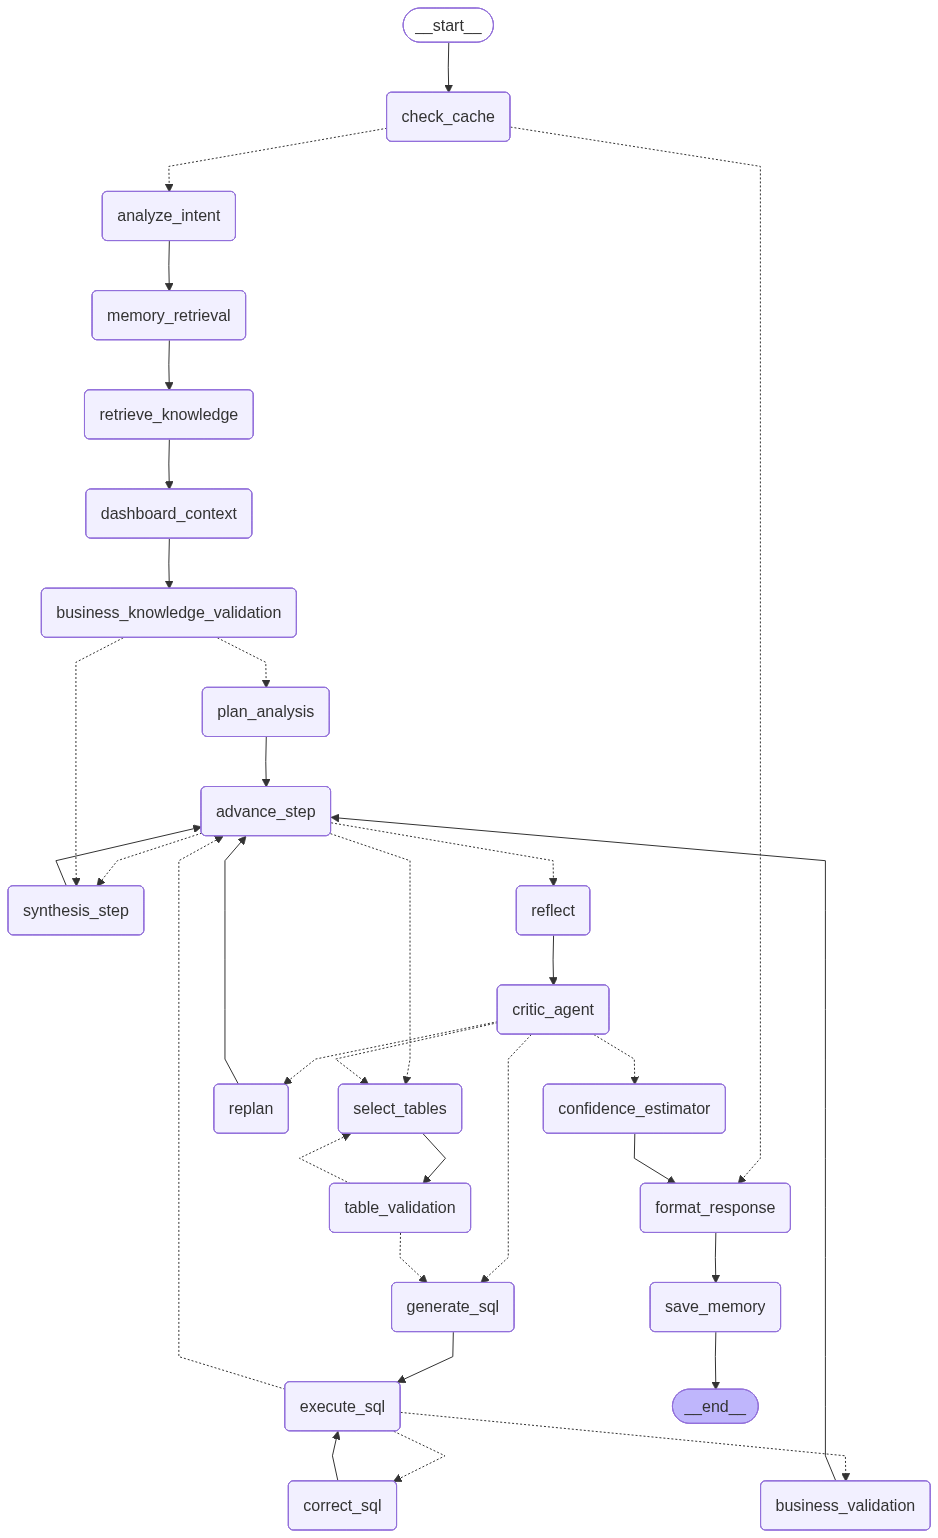

PNG renderizado


In [18]:
try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
    print('PNG renderizado')
except Exception as e:
    print(f'PNG no disponible ({type(e).__name__}). Mostrando Mermaid:')
    display(Markdown('```mermaid\n' + graph.get_graph().draw_mermaid() + '\n```'))

In [19]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	check_cache(check_cache)
	analyze_intent(analyze_intent)
	retrieve_knowledge(retrieve_knowledge)
	plan_analysis(plan_analysis)
	select_tables(select_tables)
	generate_sql(generate_sql)
	execute_sql(execute_sql)
	correct_sql(correct_sql)
	synthesis_step(synthesis_step)
	advance_step(advance_step)
	reflect(reflect)
	replan(replan)
	format_response(format_response)
	save_memory(save_memory)
	memory_retrieval(memory_retrieval)
	dashboard_context(dashboard_context)
	business_knowledge_validation(business_knowledge_validation)
	table_validation(table_validation)
	business_validation(business_validation)
	critic_agent(critic_agent)
	confidence_estimator(confidence_estimator)
	__end__([<p>__end__</p>]):::last
	__start__ --> check_cache;
	advance_step -.-> reflect;
	advance_step -.-> select_tables;
	advance_step -.-> synthesis_step;
	analyze_intent --> memory_retrieval;
	business_knowledge_validatio

---
## 7. Pruebas de Flujo

In [20]:
BASE_STATE = {
    'question': '', 'verbose': False,
    'cache_hit': False, 'cached_response': None,
    'intent': None, 'kb_context': '', 'memory_context': '', 'enriched_context': '',
    'plan': None, 'react_iteration': 0,
    'current_step_index': -1, 'current_table_sel': None,
    'current_sql': None, 'current_step_result': None, 'sql_retry_count': 0,
    'step_results': [], 'prev_results_summary': '',
    'reflection': None, 'response': None, 'trace_steps': [],
    'retrieved_memory': None,
    'kb_sufficient': False, 'kb_answer': None,
    'table_validation_ok': False, 'table_validation_issues': [],
    'table_validation_attempts': 0,
    'business_validation_ok': True, 'business_validation_flags': [],
    'critic_result': None, 'critic_iteration': 0, 'critic_target_step': -1,
    'confidence_components': None, 'final_confidence_score': 0,
    'final_confidence_action': 'respond',
    'dashboard_relevant': False, 'dashboard_reference': '',
    'dashboard_matched_measures': [], 'dashboard_context_text': '',
}


def run_and_print(question: str):
    state = {**BASE_STATE, 'question': question}
    result = graph.invoke(state)
    print(f'\n=== {question} ===')
    print(f'  kb_sufficient      : {result["kb_sufficient"]}')
    print(f'  dashboard_relevant : {result["dashboard_relevant"]}')
    if result['dashboard_relevant']:
        medidas = [m['name'] for m in result['dashboard_matched_measures']]
        print(f'  dashboard_ref      : {result["dashboard_reference"]}')
        print(f'  medidas detectadas : {medidas}')
    print(f'  pasos SQL          : {sum(1 for r in result["step_results"] if not r["sql"].startswith("--"))}')
    print(f'  biz_flags          : {result["business_validation_flags"]}')
    print(f'  critic_verdict     : {(result["critic_result"] or {}).get("verdict", "n/a")}')
    print(f'  final_score        : {result["final_confidence_score"]}')
    print(f'  final_action       : {result["final_confidence_action"]}')
    print(f'  respuesta          : {result["response"]["executive_summary"][:100]}')
    return result


# Flujo A: pregunta SQL relacionada a un dashboard (Mod 10 activo + pipeline SQL normal)
ra = run_and_print('Cual fue el GMV del mes pasado?')

# Flujo B: pregunta KB-only (sin SQL) — Mod 10 tambien puede activarse en paralelo al Mod 1
rb = run_and_print('Que es el GMV?')

# Flujo C: otra medida de dashboard distinta (Payouts Rechazados -> produccion.payouts)
rc = run_and_print('Cuantos payouts rechazados hubo este mes?')

# Flujo D: pregunta sin relacion a ningun dashboard (control negativo del Mod 10)
rd = run_and_print('Hola, como estas?')

print('\n--- Comparacion ---')
print(f'Flujo A SQL generado      : {ra["step_results"][0]["sql"][:60]}')
print(f'Flujo B SQL generado      : {rb["step_results"][0]["sql"]}')
print(f'Flujo C dashboard_context : {rc["dashboard_context_text"][:120]}')
print(f'Flujo D dashboard_relevant: {rd["dashboard_relevant"]} (esperado False, sin coincidencias)')


=== Cual fue el GMV del mes pasado? ===
  kb_sufficient      : False
  dashboard_relevant : True
  dashboard_ref      : Merchants_1, Merchants_2, Merchants_3
  medidas detectadas : ['GMV']
  pasos SQL          : 1
  biz_flags          : []
  critic_verdict     : sufficient
  final_score        : 92
  final_action       : respond
  respuesta          : El GMV del mes pasado ascendio a $1,250,000, representando el volumen total de transacciones complet

=== Que es el GMV? ===
  kb_sufficient      : True
  dashboard_relevant : True
  dashboard_ref      : Merchants_1, Merchants_2, Merchants_3
  medidas detectadas : ['GMV']
  pasos SQL          : 0
  biz_flags          : []
  critic_verdict     : sufficient
  final_score        : 92
  final_action       : respond
  respuesta          : El GMV del mes pasado ascendio a $1,250,000, representando el volumen total de transacciones complet

=== Cuantos payouts rechazados hubo este mes? ===
  kb_sufficient      : False
  dashboard_relevant : Tru

---
## 8. Referencia Completa

### Nodos

| # | Nodo | Tipo | LLM | Mod | Descripcion |
|---|---|---|---|---|---|
| 1 | `check_cache` | Original | No | — | Similitud tokens >= 80% -> HIT |
| 2 | `analyze_intent` | Original | Si | — | Clasifica dominio, complejidad, metricas |
| 3 | `retrieve_knowledge` | Original | No | Usa Mod2 | FAISS top-5 sobre 10 docs KB |
| 4 | `plan_analysis` | Original+ | Si | Mod 3 | Descomposicion subproblemas + PlanStep |
| 5 | `select_tables` | Original | Si | — | Selecciona del catalogo 13 objetos |
| 6 | `generate_sql` | Original | Si | — | SQL con reglas de negocio PayNova |
| 7 | `execute_sql` | Original | No | — | SELECT puro, max 500 filas |
| 8 | `correct_sql` | Original | Si | — | Correccion con error como contexto |
| 9 | `synthesis_step` | Original+ | No | Ext Mod1 | KB-directo o multi-hop |
| 10 | `advance_step` | Original | No | — | Consolida result, incrementa idx |
| 11 | `reflect` | Original | Si | — | Primera capa de evaluacion |
| 12 | `replan` | Original | Si | — | Replanning con contexto de error |
| 13 | `format_response` | Original+ | Si | Mod 9 | Formato CEO/CFO/COO |
| 14 | `save_memory` | Original | No | — | Persiste en memory_store.json |
| **15** | **`memory_retrieval`** | **NUEVO** | No | **Mod 2** | Historial previo antes de KB |
| **16** | **`dashboard_context`** | **NUEVO** | Si (si hay candidatos) | **Mod 10** | Detecta relevancia de dashboard PBI + reformula en terminos de datos |
| **17** | **`business_knowledge_validation`** | **NUEVO** | Si | **Mod 1** | KB-sufficient -> skip SQL |
| **18** | **`table_validation`** | **NUEVO** | Si | **Mod 4** | Cobertura metricas/entidades |
| **19** | **`business_validation`** | **NUEVO** | Si | **Mod 5** | Rangos y coherencia negocio |
| **20** | **`critic_agent`** | **NUEVO** | Si | **Mod 6+7** | LLM independiente + bucle |
| **21** | **`confidence_estimator`** | **NUEVO** | No | **Mod 8** | Score compuesto 6 componentes |

### Decisiones de Routing

| D | Fuente | Condicion | Destino |
|---|---|---|---|
| D1 | `check_cache` | cache_hit=True | `format_response` |
| D1 | `check_cache` | cache_hit=False | `analyze_intent` |
| **D2** | `business_knowledge_validation` | kb_sufficient=True | `synthesis_step` (sin SQL) |
| **D2** | `business_knowledge_validation` | kb_sufficient=False | `plan_analysis` |
| **D3** | `table_validation` | ok=True o agotado | `generate_sql` |
| **D3** | `table_validation` | ok=False y retries < 2 | `select_tables` |
| D4 | `execute_sql` | success=True | `business_validation` *(antes: advance_step)* |
| D4 | `execute_sql` | failure + retries | `correct_sql` |
| D4 | `execute_sql` | failure agotado | `advance_step` |
| D5 | `advance_step` | idx >= len(steps) | `reflect` |
| D5 | `advance_step` | is_synthesis=True | `synthesis_step` |
| D5 | `advance_step` | is_synthesis=False | `select_tables` |
| **D6** | `critic_agent` | sufficient o iters agotadas | `confidence_estimator` |
| **D6** | `critic_agent` | replan | `replan` |
| **D6** | `critic_agent` | retable | `select_tables` (paso N) |
| **D6** | `critic_agent` | retry_sql | `generate_sql` (paso N) |

`dashboard_context` (Mod 10) **no** agrega una decision de routing: es una arista fija
(`retrieve_knowledge -> dashboard_context -> business_knowledge_validation`), a diferencia
de Mod 1 que si bifurca. Su efecto es indirecto: enriquece `enriched_context`, lo que puede
influir en `plan_analysis` y `generate_sql` aguas abajo, pero nunca salta el pipeline SQL.

### Flujos de Referencia

**KB-only** (`Que es el GMV?`):
```
check_cache -> analyze_intent -> memory_retrieval -> retrieve_knowledge
-> dashboard_context [dashboard_relevant=True, GMV tambien es medida de dashboard]
-> business_knowledge_validation [kb_sufficient=True]
-> synthesis_step -> advance_step -> reflect -> critic_agent
-> confidence_estimator -> format_response -> save_memory
```

**SQL simple relacionado a un dashboard** (`Cual fue el GMV del mes pasado?`):
```
... -> retrieve_knowledge -> dashboard_context [dashboard_relevant=True,
       antepone medidas DAX + tablas SQL reales a enriched_context]
-> business_knowledge_validation [needs_sql] -> plan_analysis -> advance_step
-> select_tables -> table_validation -> generate_sql -> execute_sql
-> business_validation -> advance_step -> reflect -> critic_agent
-> confidence_estimator -> format_response -> save_memory
```

**Pregunta sin relacion a ningun dashboard** (`Hola, como estas?`):
```
... -> retrieve_knowledge -> dashboard_context [dashboard_relevant=False, sin cambios
       a enriched_context] -> business_knowledge_validation -> ...
```

**Critic pide retry SQL en paso N:**
```
... -> critic_agent [retry_sql, target=N] -> generate_sql -> execute_sql
-> business_validation -> advance_step -> reflect -> critic_agent [sufficient]
-> confidence_estimator -> format_response
```

**Confianza insuficiente (score < 50):**
```
... -> confidence_estimator [score=42, action=clarify]
-> format_response [genera solicitud de aclaracion al usuario]
```